### 🎯 Project Objective

To predict students’ final academic performance (G3) using demographic factors, family and social background, academic history, and lifestyle habits.

The goal is to:
- Identify key drivers influencing final grades
- Build a Linear Regression model to predict performance
- Apply Ridge Regression to improve model stability
- Compare performances using MSE and R²
- Generate insights that help schools identify at-risk students early and provide timely academic support.

## Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Load the dataset and analyse it

In [2]:
df = pd.read_csv("student-por.csv")

df.head()
df.describe(include="all")
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

### Target distribution - histplot

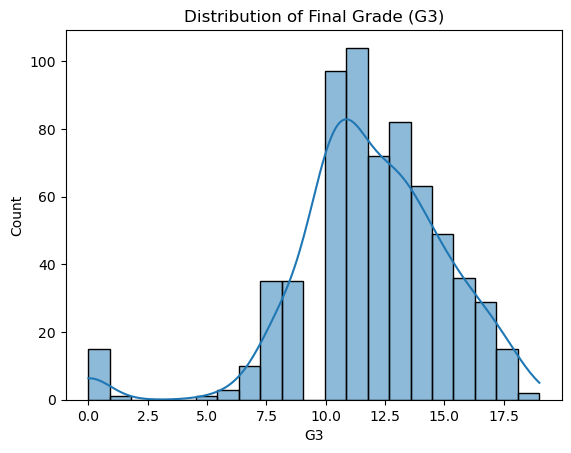

In [4]:
plt.figure()
sns.histplot(df["G3"], kde = True)
plt.title("Distribution of Final Grade (G3)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\04_linear_and_ridge_regression_student_performance\images\finalgradeG3_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key Insights

- Grades are clustered between 10-15
- Very few students score below 5 or above 18
- Distribution is slightly right-skewed
- A few zero-grade outliers exist (likely failures/absences)

### Correlation heatmap

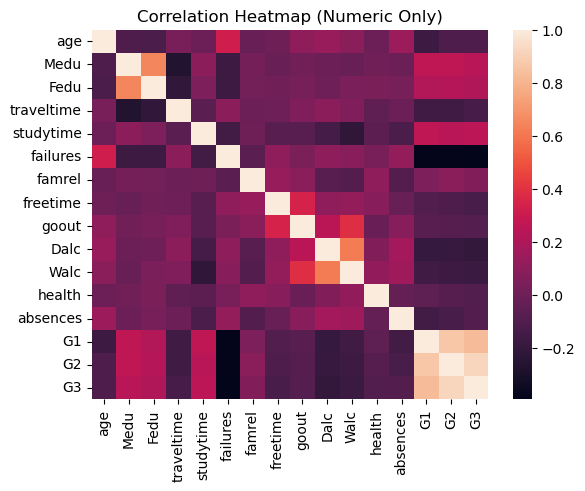

In [7]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Heatmap (Numeric Only)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\04_linear_and_ridge_regression_student_performance\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key insights

- G3 is highly correlated with G2 and G1
    - prior performance is the strongest predictor
- Past failures show negative correlation with G3
- Daily/Weekend alcohol use shows mild negative relation
- Absences have weak-to-moderate negative relation
- Most other features have weak correlations

### Prepare data for modeling

In [8]:
target = "G3"
X = df.drop(columns=[target])
y = df[target]

### Train-Test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Separate numeric and categorical data

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### Ridge regression model

In [16]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_ridge, r2_ridge

(1.4632793210906152, 0.84994647868722)

### Ridge regression - Actual vs Predicted

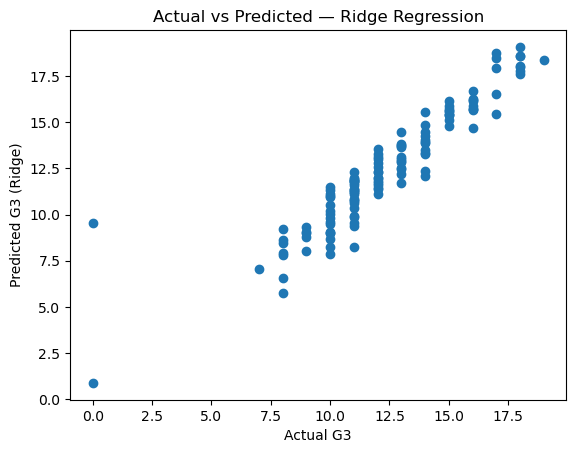

In [17]:
plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3 (Ridge)")
plt.title("Actual vs Predicted — Ridge Regression")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\ref\04_linear_and_ridge_regression_student_performance\images\actual_vs_predicted_ridge_reg.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 📌 Key insights and learning summary

Initial model using linear regression and improvement using ridge regression

🎯 Model Performance

- Ridge Regression
    - MSE: 1.4741
    - R² Score: 0.8488

The model explains ~84.9% of the variation in students' final grades (G3), indicating strong predictive performance.

### 🧠 Key Learning Outcomes

- Past academic performance (G1 & G2) is by far the strongest predictor of final grades
- The model demonstrates high stability due to regularization, which reduces the impact of multicollinearity among features
- The dataset contains low noise, allowing the model to generalize well to unseen data
- Lifestyle and demographic factors have comparatively weaker influence than academic history
- Regularization helps prevent overfitting while keeping prediction accuracy high

### 📊 Model Interpretation

Ridge Regression shrinks less important feature coefficients while retaining the most informative predictors. This ensures:

✔ More stable predictions  
✔ Better handling of correlated inputs  
✔ Reduced risk of overfitting  

### 🏁 Conclusion

- Ridge Regression provides robust and reliable grade predictions
- The model generalizes well and maintains strong accuracy
- Early academic indicators are critical for forecasting final outcomes

### 💼 Key Educational Insight

Monitoring early-term grades (G1 and G2) enables schools to identify at-risk students early, allowing timely academic support, mentoring, and performance improvement interventions.

In [19]:
import joblib

# Save the entire pipeline (preprocessing + model)
joblib.dump(ridge_model, "ridge_student_performance_model.pkl")

['ridge_student_performance_model.pkl']